In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [10]:
resnet_5 = pd.read_csv("../outputs/model_results/resnet18_5epoch_summary.csv")
resnet_10 = pd.read_csv("../outputs/model_results/resnet18_10epoch_summary.csv")

densenet_5 = pd.read_csv("../outputs/model_results/densenet121_5epoch_summary.csv")
densenet_10 = pd.read_csv("../outputs/model_results/densenet121_10epoch_summary.csv")

efficientnet_5 = pd.read_csv("../outputs/model_results/efficientnet_b0_5epoch_summary.csv")
efficientnet_10 = pd.read_csv("../outputs/model_results/efficientnet_b0_10epoch_summary.csv")

In [20]:
all_summaries = pd.concat([
    resnet_5,
    resnet_10,
    densenet_5,
    densenet_10,
    efficientnet_5,
    efficientnet_10
], ignore_index=True)

all_summaries = all_summaries.drop_duplicates(
    subset=["Model", "Epoch"],
    keep="first"
).reset_index(drop=True)

all_summaries

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ResNet18,5,91.214953,91.214953,93.177570,0.963855,0.897196,0.929332,0.986193
1,ResNet18,10,94.018692,94.018692,95.327103,0.953271,0.953271,0.953271,0.990822
2,DenseNet121,5,90.654206,90.654206,90.280374,0.907372,0.897196,0.902256,0.972626
3,DenseNet121,10,92.710280,92.710280,92.336449,0.938104,0.906542,0.922053,0.982727
4,EfficientNet-B0,5,87.663551,87.663551,90.654206,0.941176,0.867290,0.902724,0.966401
5,EfficientNet-B0,10,90.934579,90.934579,92.523364,0.915905,0.936449,0.926063,0.979233


In [21]:
comparison_table = all_summaries[
    [
        "Model",
        "Epoch",
        "Best Validation Accuracy",
        "Final Validation Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

comparison_table = comparison_table.sort_values(
    by=["Epoch", "Test Accuracy"],
    ascending=[True, False]
)

comparison_table.reset_index(drop=True, inplace=True)

comparison_table

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ResNet18,5,91.214953,91.214953,93.177570,0.963855,0.897196,0.929332,0.986193
1,EfficientNet-B0,5,87.663551,87.663551,90.654206,0.941176,0.867290,0.902724,0.966401
2,DenseNet121,5,90.654206,90.654206,90.280374,0.907372,0.897196,0.902256,0.972626
3,ResNet18,10,94.018692,94.018692,95.327103,0.953271,0.953271,0.953271,0.990822
4,EfficientNet-B0,10,90.934579,90.934579,92.523364,0.915905,0.936449,0.926063,0.979233
5,DenseNet121,10,92.710280,92.710280,92.336449,0.938104,0.906542,0.922053,0.982727


In [13]:
comparison_table.to_csv(
    "../outputs/model_results/final_model_comparison.csv",
    index=False
)

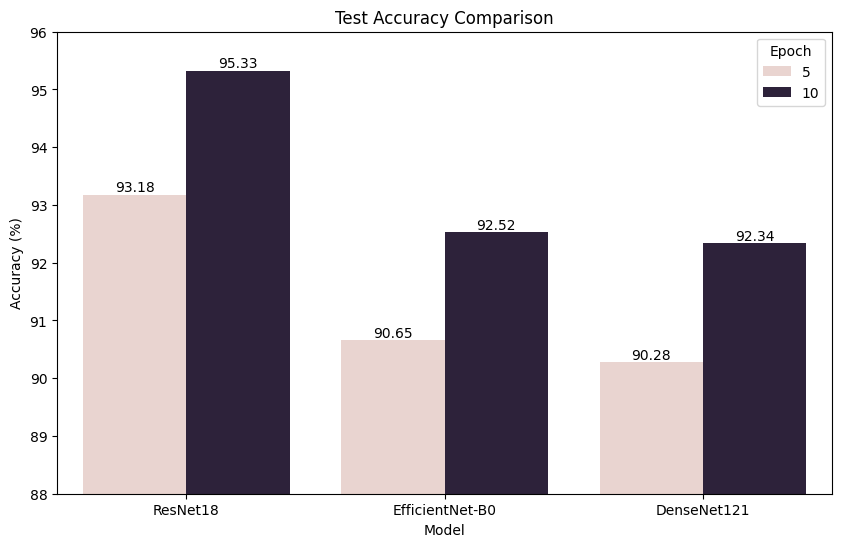

In [16]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=comparison_table,
    x="Model",
    y="Test Accuracy",
    hue="Epoch"
)

plt.ylim(88, 96)      # önemli

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

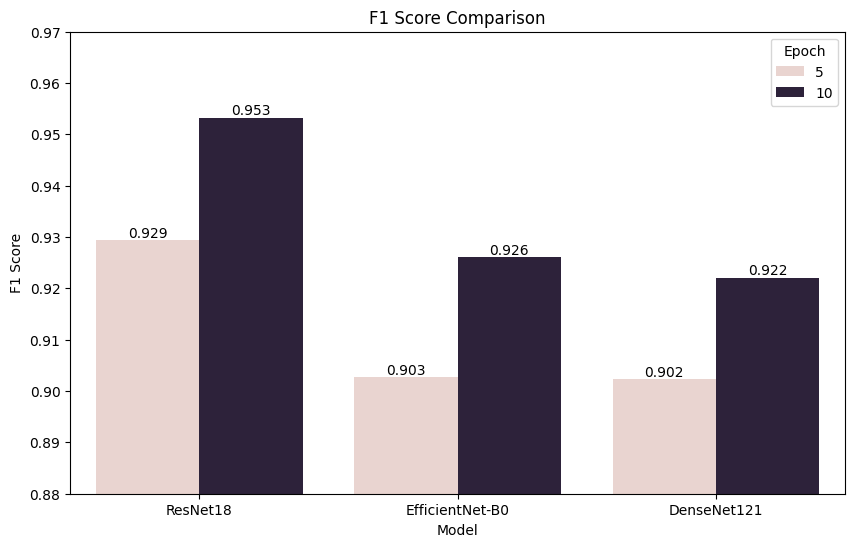

In [17]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=comparison_table,
    x="Model",
    y="F1-Score",
    hue="Epoch"
)

plt.ylim(0.88, 0.97)   # önemli

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

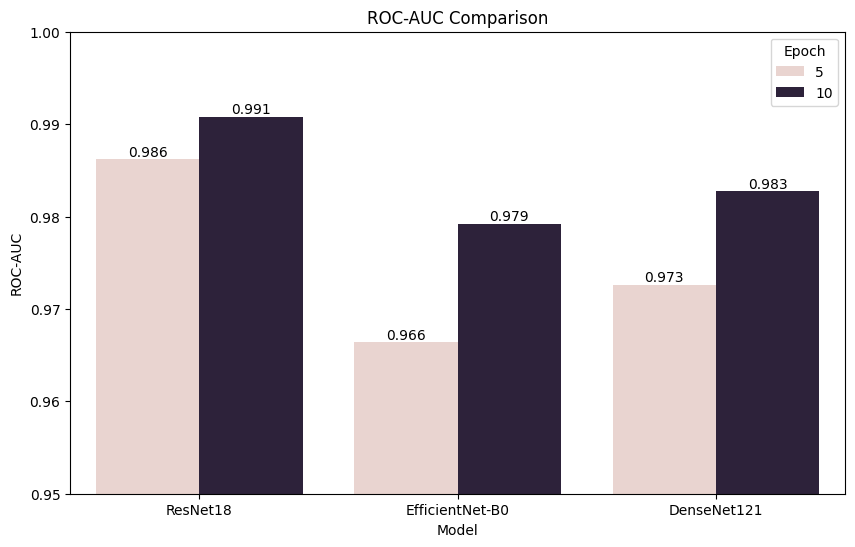

In [18]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=comparison_table,
    x="Model",
    y="ROC-AUC",
    hue="Epoch"
)

plt.ylim(0.95, 1.00)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.show()

In [22]:
comparison_table_display = comparison_table.copy()

comparison_table_display[
    [
        "Best Validation Accuracy",
        "Final Validation Accuracy",
        "Test Accuracy"
    ]
] = comparison_table_display[
    [
        "Best Validation Accuracy",
        "Final Validation Accuracy",
        "Test Accuracy"
    ]
].round(2)

comparison_table_display[
    [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
] = comparison_table_display[
    [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].round(3)

comparison_table_display

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ResNet18,5,91.21,91.21,93.18,0.964,0.897,0.929,0.986
1,EfficientNet-B0,5,87.66,87.66,90.65,0.941,0.867,0.903,0.966
2,DenseNet121,5,90.65,90.65,90.28,0.907,0.897,0.902,0.973
3,ResNet18,10,94.02,94.02,95.33,0.953,0.953,0.953,0.991
4,EfficientNet-B0,10,90.93,90.93,92.52,0.916,0.936,0.926,0.979
5,DenseNet121,10,92.71,92.71,92.34,0.938,0.907,0.922,0.983
